# **Question 1: Fine-Tune EfficientNetV2-Medium for Bone Fracture Classification**

##### This dataset contains **X-ray images** of various types of bone fractures, categorized into **12 classes**.

##### Complete the tasks below to fine-tune a **pretrained EfficientNetV2-Medium** model on this dataset to classify bone fractures.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# # Please uncomment this out when you are running this lab on google colab!
# import os

# # Set KaggleHub cache to a directory inside /content/
# os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shyamgupta196/bone-fracture-split-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/bone-fracture-split-classification


In [ ]:
class_to_idx = {
    "Avulsion fracture": 0,
    "Comminuted fracture": 1,
    "Compression-Crush fracture": 2,
    "Fracture Dislocation": 3,
    "Greenstick fracture": 4,
    "Hairline Fracture": 5,
    "Impacted fracture": 6,
    "Intra-articular fracture": 7,
    "Longitudinal fracture": 8,
    "Oblique fracture": 9,
    "Pathological fracture": 10,
    "Spiral Fracture": 11
}


# TASK 1: Dataset Class & Dataloader

### Note: You can build a custom dataset class or use any torch built-in dataset classes (e.g. TensorDataset, ImageFolder,...)

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                          std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                          std=[0.229, 0.224, 0.225])
])


# Create dataset objects
train_dataset = ImageFolder(os.path.join(path,"train"), transform=transform)
valid_dataset = ImageFolder(os.path.join(path,"test"), transform=test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)

# Check a batch of images
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels}")

Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([ 1,  4,  6,  2,  3,  1,  2,  0,  4,  8, 11, 11, 11,  0,  9,  8,  9,  6,
         7,  9,  7,  4,  4,  1,  1,  3, 10,  2,  2,  0, 11,  8])


## TASK 2: Display some images from the dataset

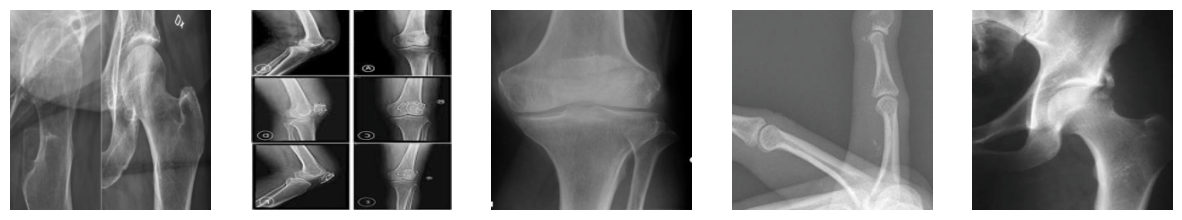

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Define mean & std for denormalization (EfficientNet Preprocessing)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Display 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

imgs_indices = [270,233,110,89,15]

for i in range(5):
    img, label = train_dataset[imgs_indices[i]]  # Load image & label

    # Convert tensor to numpy for visualization
    img_np = img.numpy().transpose(1, 2, 0)  # (C, H, W) → (H, W, C)

    # Denormalize the image
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Show image
    axes[i].imshow(img_np)
    axes[i].axis('off')

plt.show()

# TASK 3: Define the Model

### You should finetune EfficientNetV2 Medium. Can be imported as follows:

from torchvision.models import efficientnet_v2_m

In [ ]:
from torchvision import models

# Load pretrained EfficientNet-B0
model = models.efficientnet_v2_m(pretrained=True)

# Modify the classifier 
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 12)  

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

# TASK 4: Training and Validation Loops

In [21]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)

        
        outputs = model(images).squeeze()  # The model outputs in shape [batch_size,1]. We convert them to [batch_size,] so the loss accepts them.
        loss = criterion(outputs, labels)  

        optimizer.zero_grad()  
        loss.backward()  
        optimizer.step()  

        total_loss += loss.item()

        # Track accuracy
        predictions = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(predictions, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  
    return avg_loss, accuracy

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()  
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze()  # The model outputs in shape [batch_size,1]. We convert them to [batch_size,] so the loss accepts them.
            loss = criterion(outputs, labels)  
            total_loss += loss.item()

            # Compute accuracy
            predictions = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(predictions,dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total  
    return avg_loss, accuracy


# TASK 5: Running Training 

## (Bonus Task: Reach 50% Accuracy in the validation set. You may want to tune the learning rate and number of epochs)

In [22]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  
optimizer = optim.Adam(model.parameters(), lr=0.0001)  
num_epochs = 20 # Number of epochs


# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training process
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, valid_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")


  0%|          | 0/37 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 37/37 [00:16<00:00,  2.20it/s]


Epoch 1/20: Train Loss=2.4198, Train Accuracy=16.40%, Val Loss=2.2858, Val Accuracy=30.29%


 30%|██▉       | 11/37 [00:05<00:11,  2.34it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 54%|█████▍    | 20/37 [00:09<00:07,  2.37it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 37/37 [00:16<00:00,  2.28it/s]


Epoch 2/20: Train Loss=1.9417, Train Accuracy=38.77%, Val Loss=2.0476, Val Accuracy=35.53%


 41%|████      | 15/37 [00:06<00:09,  2.37it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 37/37 [00:15<00:00,  2.32it/s]


...

Epoch 18/20: Train Loss=0.2563, Train Accuracy=88.30%, Val Loss=2.4902, Val Accuracy=49.71%


 30%|██▉       | 11/37 [00:05<00:11,  2.33it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 37/37 [00:16<00:00,  2.24it/s]


Epoch 19/20: Train Loss=0.2473, Train Accuracy=88.90%, Val Loss=2.3855, Val Accuracy=46.80%


  5%|▌         | 2/37 [00:01<00:22,  1.55it/s]/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 37/37 [00:16<00:00,  2.31it/s]


Epoch 20/20: Train Loss=0.2209, Train Accuracy=89.24%, Val Loss=2.4957, Val Accuracy=47.96%


# TASK 6: Plot Loss & Accuracy

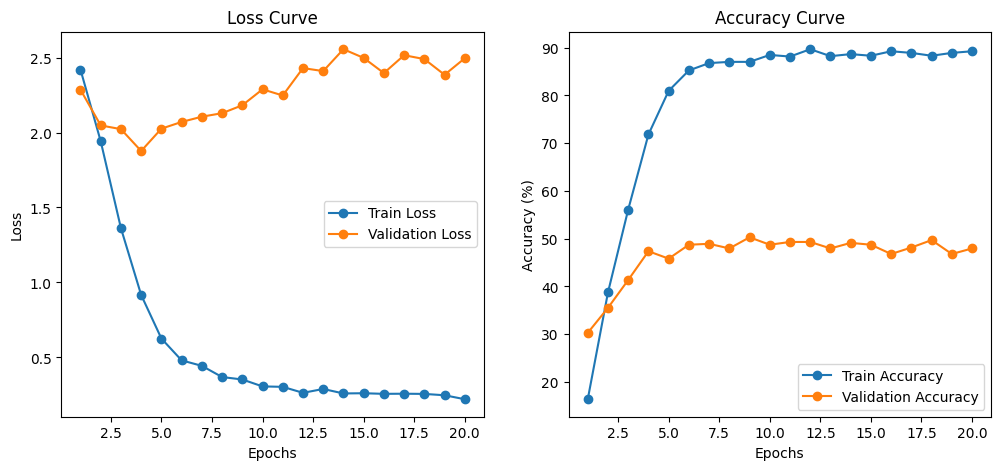

In [23]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


# BONUS Task: K-Fold Cross-Validation

Implement 5-fold cross-validation on the training dataset and print the accuracy scores for each fold by applying these steps:
- Use the `glob` module to collect image file paths from your training dataset.
- Create a pandas DataFrame that contains the file paths and corresponding labels.
- Implement `KFold` loop to split the DataFrame into training and validation folds.
- Inside the KFold loop, initialize your train and validation dataloaders, model and run the training.



class_to_idx = {
    "Avulsion fracture": 0,
    "Comminuted fracture": 1,
    "Compression-Crush fracture": 2,
    "Fracture Dislocation": 3,
    "Greenstick fracture": 4,
    "Hairline Fracture": 5,
    "Impacted fracture": 6,
    "Intra-articular fracture": 7,
    "Longitudinal fracture": 8,
    "Oblique fracture": 9,
    "Pathological fracture": 10,
    "Spiral Fracture": 11
}


In [ ]:
image_paths = []
labels = []
import glob
for class_name, label in class_to_idx.items():
        class_images = glob.glob(f"{path}/train/{class_name}/*")  # Find all images
        image_paths.extend(class_images)
        labels.extend([label] * len(class_images))  # Assign labels

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class BonesDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths  # List of image paths
        self.labels = labels  # Corresponding labels
        self.transform = transform  # Transformations to apply

    def __len__(self):
        return len(self.image_paths)  # Total number of images

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]  # Get image path
        label = self.labels[idx]  # Get corresponding label
        
        # Load image
        image = Image.open(image_path)

        # Apply transformations (if any)
        if self.transform:
            image = self.transform(image)

        return image, label  # Return processed image and its label

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# Define K-Fold Cross Validator
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store accuracy for each fold
fold_accuracies = []

# Convert train image paths into numpy array for indexing
train_image_paths = np.array(image_paths)

transform = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Flip images randomly
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # These random ahh values were found using ImageNet dataset, https://paperswithcode.com/dataset/imagenet
                          std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # These random ahh values were found using ImageNet dataset, https://paperswithcode.com/dataset/imagenet
                          std=[0.229, 0.224, 0.225])
])


for fold, (train_idx, val_idx) in enumerate(kf.split(train_image_paths)):
    print(f"\n🚀 Training Fold {fold+1}/{k_folds}")

    # Split dataset
    train_subset = [train_image_paths[i] for i in train_idx]
    val_subset = [train_image_paths[i] for i in val_idx]

    # Create datasets and dataloaders
    train_dataset = BonesDataset(image_paths,labels, transform=transform)
    val_dataset = BonesDataset(image_paths,labels, transform=test_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # Load Pretrained Model for each fold
    model = models.efficientnet_v2_m(pretrained=True)
    model.classifier = nn.Linear(model.classifier[1].in_features, 12)  # Modify classifier
    model = model.to(device)

    # Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    # Train for a few epochs
    num_epochs = 5  # Reduce epochs to keep it efficient

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        print(f"Fold {fold+1} | Epoch {epoch+1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}%")

    # Store final validation accuracy for this fold
    fold_accuracies.append(val_acc)

# Print final results
print("\n✅ **K-Fold Cross Validation Results:**")
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1}: {acc:.2f}% Accuracy")
